# RT vs error rate per multiplication fact

One point per directional fact (`a×b`), one panel per classroom course age. Source: A998 fluency test.
Facts involving 0 are highlighted. See `DECISIONS.txt` for the filters behind the query.

In [1]:
import re, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
from plot_style import C_OTHER, C_ZERO, FONT_BIG, FONT_MED, paint_it_black, set_style

SQL = ROOT / "queries/rt_error_by_fact_age.sql"
SQL_COUNTRY = ROOT / "queries/rt_error_by_fact_age_country.sql"
PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
set_style()

In [2]:
def load_facts(year):
    sql = re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", SQL.read_text(encoding="utf-8"))
    df = cached_query(SQL, cache_dir=ROOT / "cache", sql_text=sql)
    df["has_zero"] = df.left_factor.eq(0) | df.right_factor.eq(0)
    return df

def load_group(countries):
    in_list = ", ".join(f"'{c}'" for c in countries)
    sql = re.sub(r"IN \([^)]*\)(?=\s+-- \{COUNTRIES\})", f"IN ({in_list})",
                 SQL_COUNTRY.read_text(encoding="utf-8"))
    df = cached_query(SQL_COUNTRY, cache_dir=ROOT / "cache", sql_text=sql)
    df["has_zero"] = df.left_factor.eq(0) | df.right_factor.eq(0)
    return df

def plot_facts(df, stem):
    ages = sorted(df.course_age.unique())
    ncols = min(4, len(ages)); nrows = -(-len(ages) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax, age in zip(axes.flat, ages):
        d = df[df.course_age.eq(age)]
        ax.scatter(d.loc[~d.has_zero, "median_rt_correct"], d.loc[~d.has_zero, "error_rate"],
                   s=55, color=C_OTHER, edgecolor="none", label="Other facts")
        ax.scatter(d.loc[d.has_zero, "median_rt_correct"], d.loc[d.has_zero, "error_rate"],
                   s=70, color=C_ZERO, edgecolor="black", linewidth=0.5, label="Facts with 0")
        ax.set_title(f"Age {age}", fontsize=FONT_MED, color="black")
        if not d.has_zero.any():
            ax.text(0.97, 0.04, "0-facts not administered", transform=ax.transAxes,
                    ha="right", fontsize=13, color="black")
        sns.despine(ax=ax)
    for ax in axes.flat[len(ages):]:
        ax.set_visible(False)
    legend_ax = next((a for a, g in zip(axes.flat, ages) if df[df.course_age.eq(g)].has_zero.any()), axes.flat[0])
    legend_ax.legend(frameon=False, fontsize=FONT_MED, loc="upper left")
    fig.supxlabel("Median response time (s)", fontsize=FONT_BIG, color="black")
    fig.supylabel("Error rate", fontsize=FONT_BIG, color="black")
    fig.tight_layout()
    paint_it_black(axes)
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")
    return fig

## Coverage by country

In [3]:
coverage = cached_query(ROOT / "queries/country_coverage.sql", cache_dir=ROOT / "cache")
coverage.assign(pct_zero_facts=(100 * coverage.n_zero_fact_responses / coverage.n_responses).round(1))

,country,n_responses,n_zero_fact_responses,n_years,n_ages,min_age,max_age,pct_zero_facts
0,ES,11104375,1326292,4,8,8,15,11.9
1,MX,1387384,138743,5,6,8,13,10.0
2,IT,579656,16086,4,4,8,11,2.8
3,US,137560,4312,4,5,8,13,3.1
4,EC-SI,127827,11419,3,4,8,11,8.9
5,CO-B,83697,7071,3,4,8,11,8.4
6,CL,34782,4290,1,4,8,11,12.3
7,EC-CO,30461,4175,1,4,8,11,13.7
8,BR,10797,83,3,3,8,10,0.8
9,CO-A,9306,1265,3,4,8,11,13.6


In [4]:
counts = cached_query(ROOT / "queries/fact_counts_by_country_age.sql", cache_dir=ROOT / "cache")
counts["zero"] = counts.operation.str.startswith("0") | counts.operation.str.endswith("0")
facts_ge30 = (counts.assign(ok=counts.n_responses.ge(30))
              .pivot_table(index="country", columns="course_age", values="ok", aggfunc="sum")
              .fillna(0).astype(int))
facts_ge30  # facts (of 100) reaching the 30-response minimum, all years pooled

course_age,8,9,10,11,12,13,14,15
country,,,,,,,,
BR,72,0,0,0,0,0,0,0
CL,72,100,100,100,0,0,0,0
CO-A,68,3,8,4,0,0,0,0
CO-B,72,100,100,100,0,0,0,0
EC-CO,72,100,100,100,0,0,0,0
EC-SI,72,100,100,100,0,0,0,0
ES,80,100,100,100,100,100,100,100
IT,72,100,100,0,0,0,0,0
MX,72,100,100,100,100,100,0,0


## Spain, 2025-26 (`ES_2025`)

,facts,zero_facts,responses
course_age,,,
8,72,0,1004633
9,100,19,1081009
10,100,19,739107
11,100,19,830944
12,100,19,379036
13,100,19,388620
14,100,19,199764
15,100,19,57363


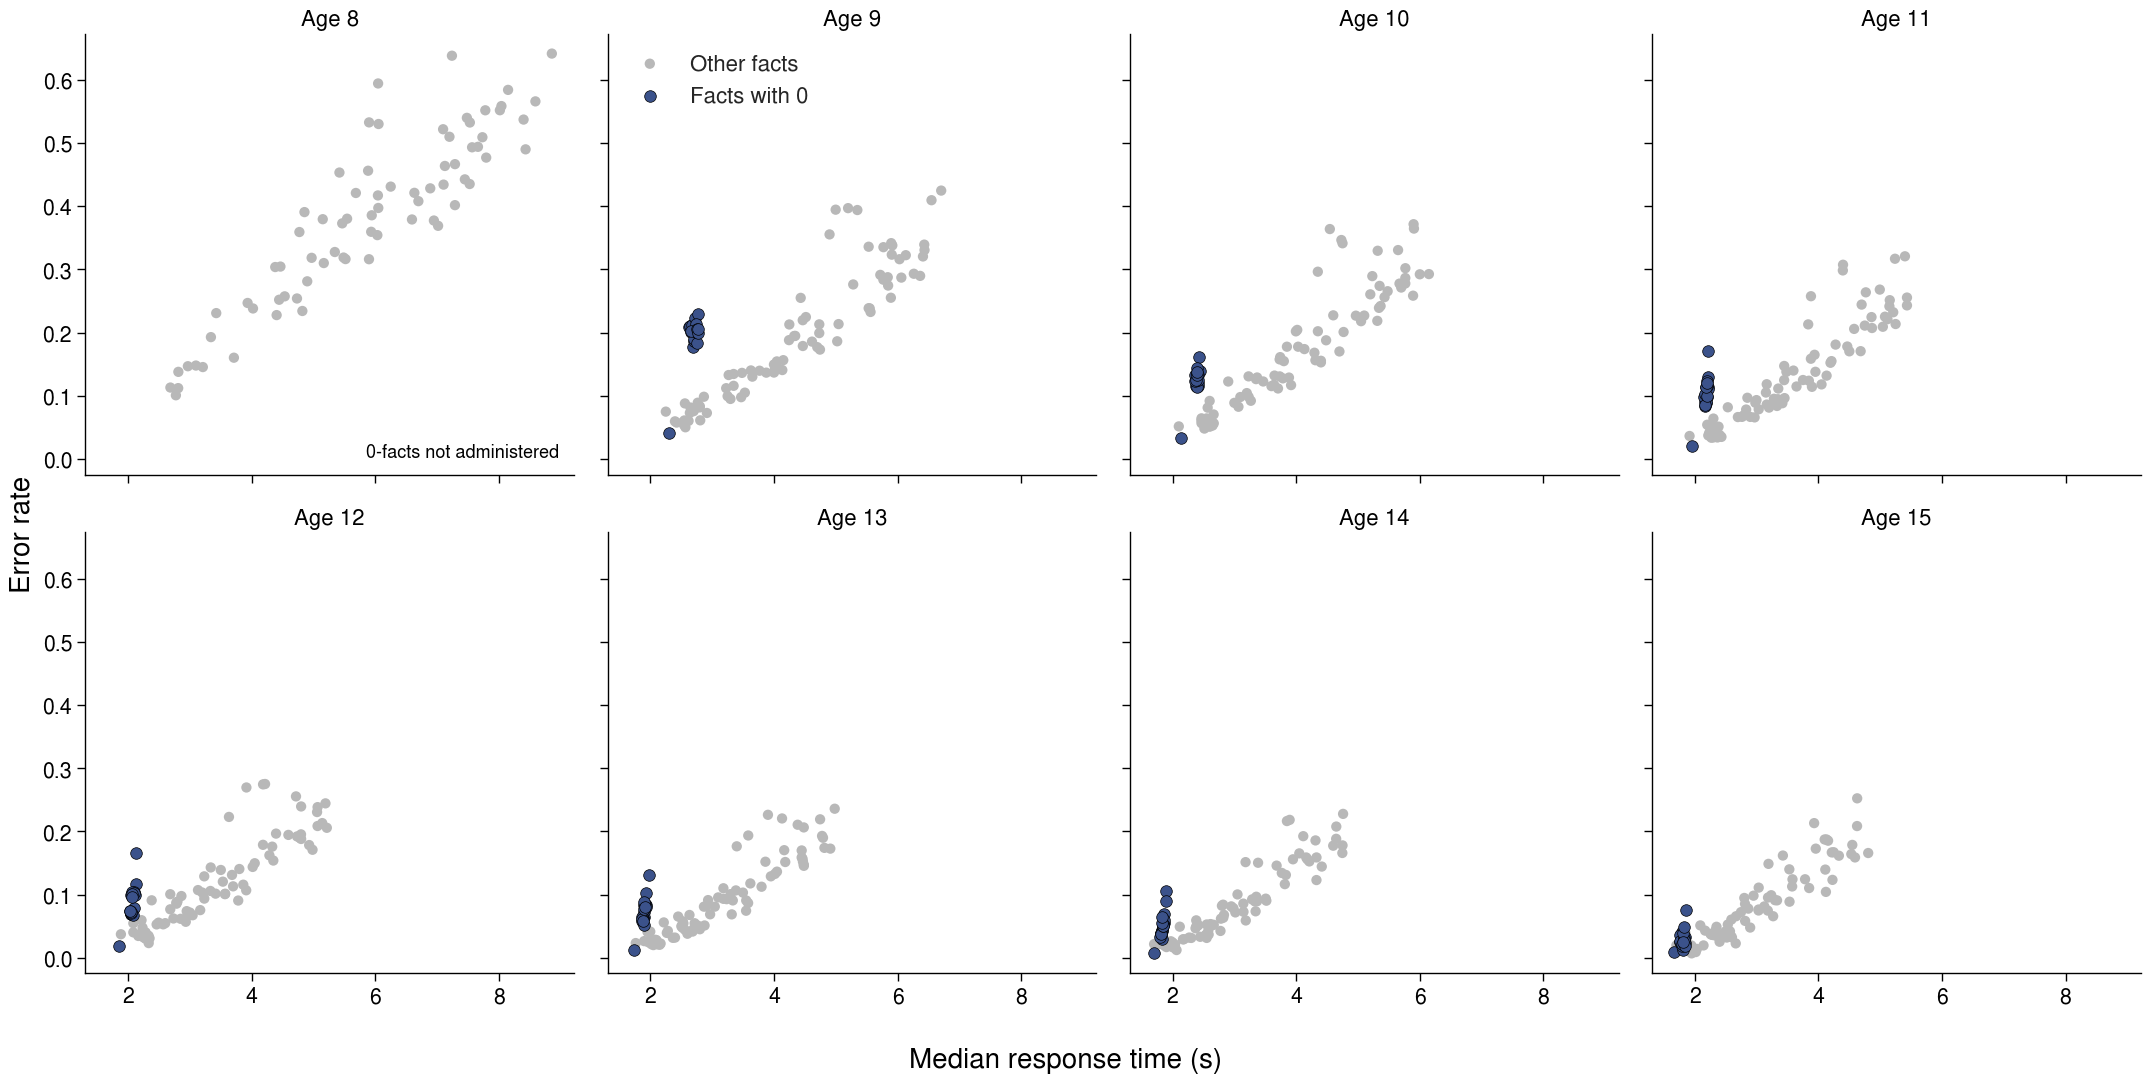

In [5]:
df_es_2025 = load_facts("ES_2025")
display(df_es_2025.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                       responses=("n_responses", "sum")))
plot_facts(df_es_2025, "rt_error_scatter_by_age_ES_2025");

## Spain, 2024-25 (`ES_2024`)

,facts,zero_facts,responses
course_age,,,
8,72,0,1146845
9,100,19,665673
10,100,19,694382
11,100,19,665725
12,100,19,123417
13,100,19,109004
14,100,19,55829
15,84,12,3049


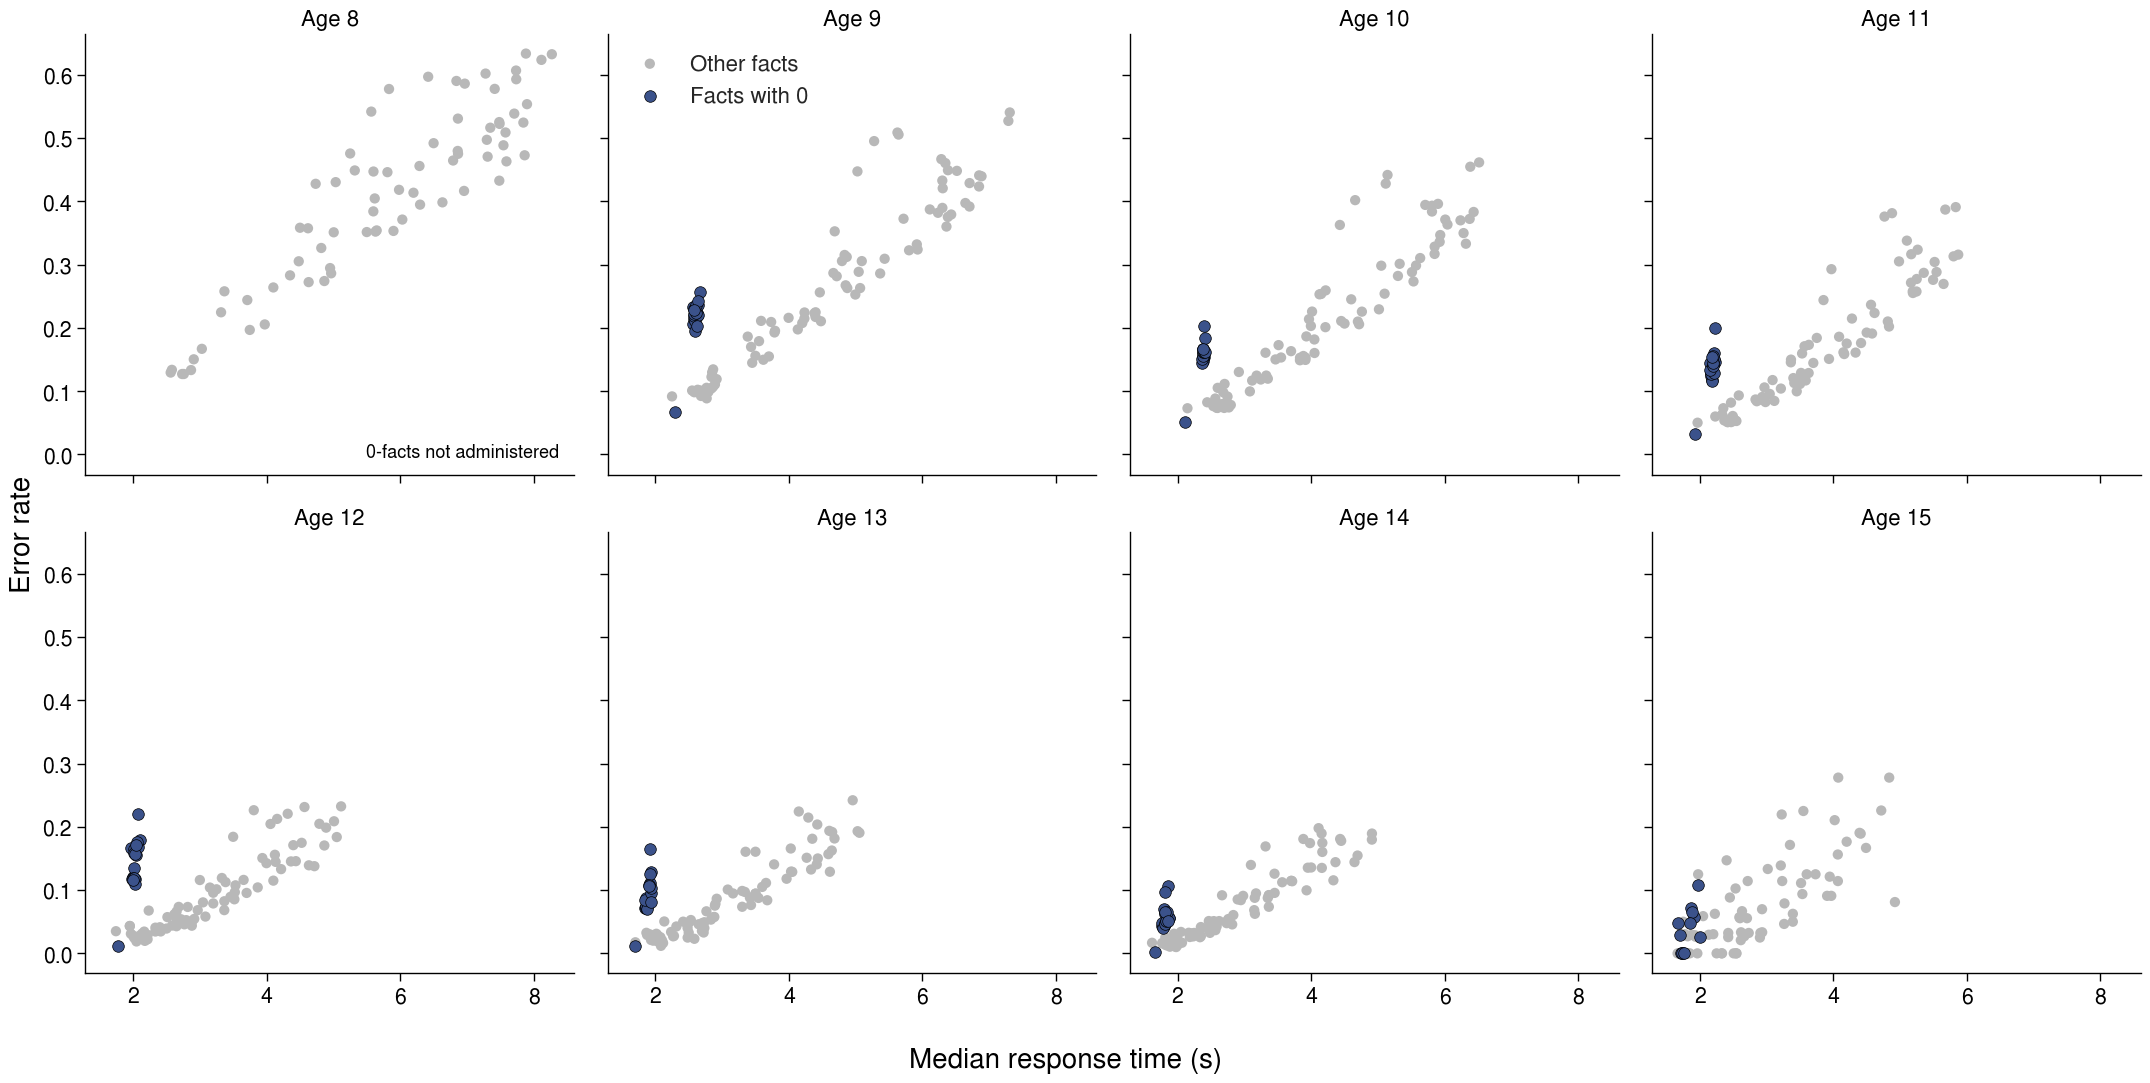

In [6]:
df_es_2024 = load_facts("ES_2024")
display(df_es_2024.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                       responses=("n_responses", "sum")))
plot_facts(df_es_2024, "rt_error_scatter_by_age_ES_2024");

## Country groups, all academic years pooled

The smallest grouping that represents every country and still clears the 30-response minimum on
all 100 facts. Six countries stand alone; only Colombia's two sources and Brazil need a partner
(Brazil has ~650 responses per age beyond age 8, so no fact of its own reaches 30).

### Spain

,facts,zero_facts,responses
course_age,,,
8,80,0,2803859
9,100,19,2393233
10,100,19,2141883
11,100,19,1902979
12,100,19,820642
13,100,19,679046
14,100,19,301593
15,100,19,60856


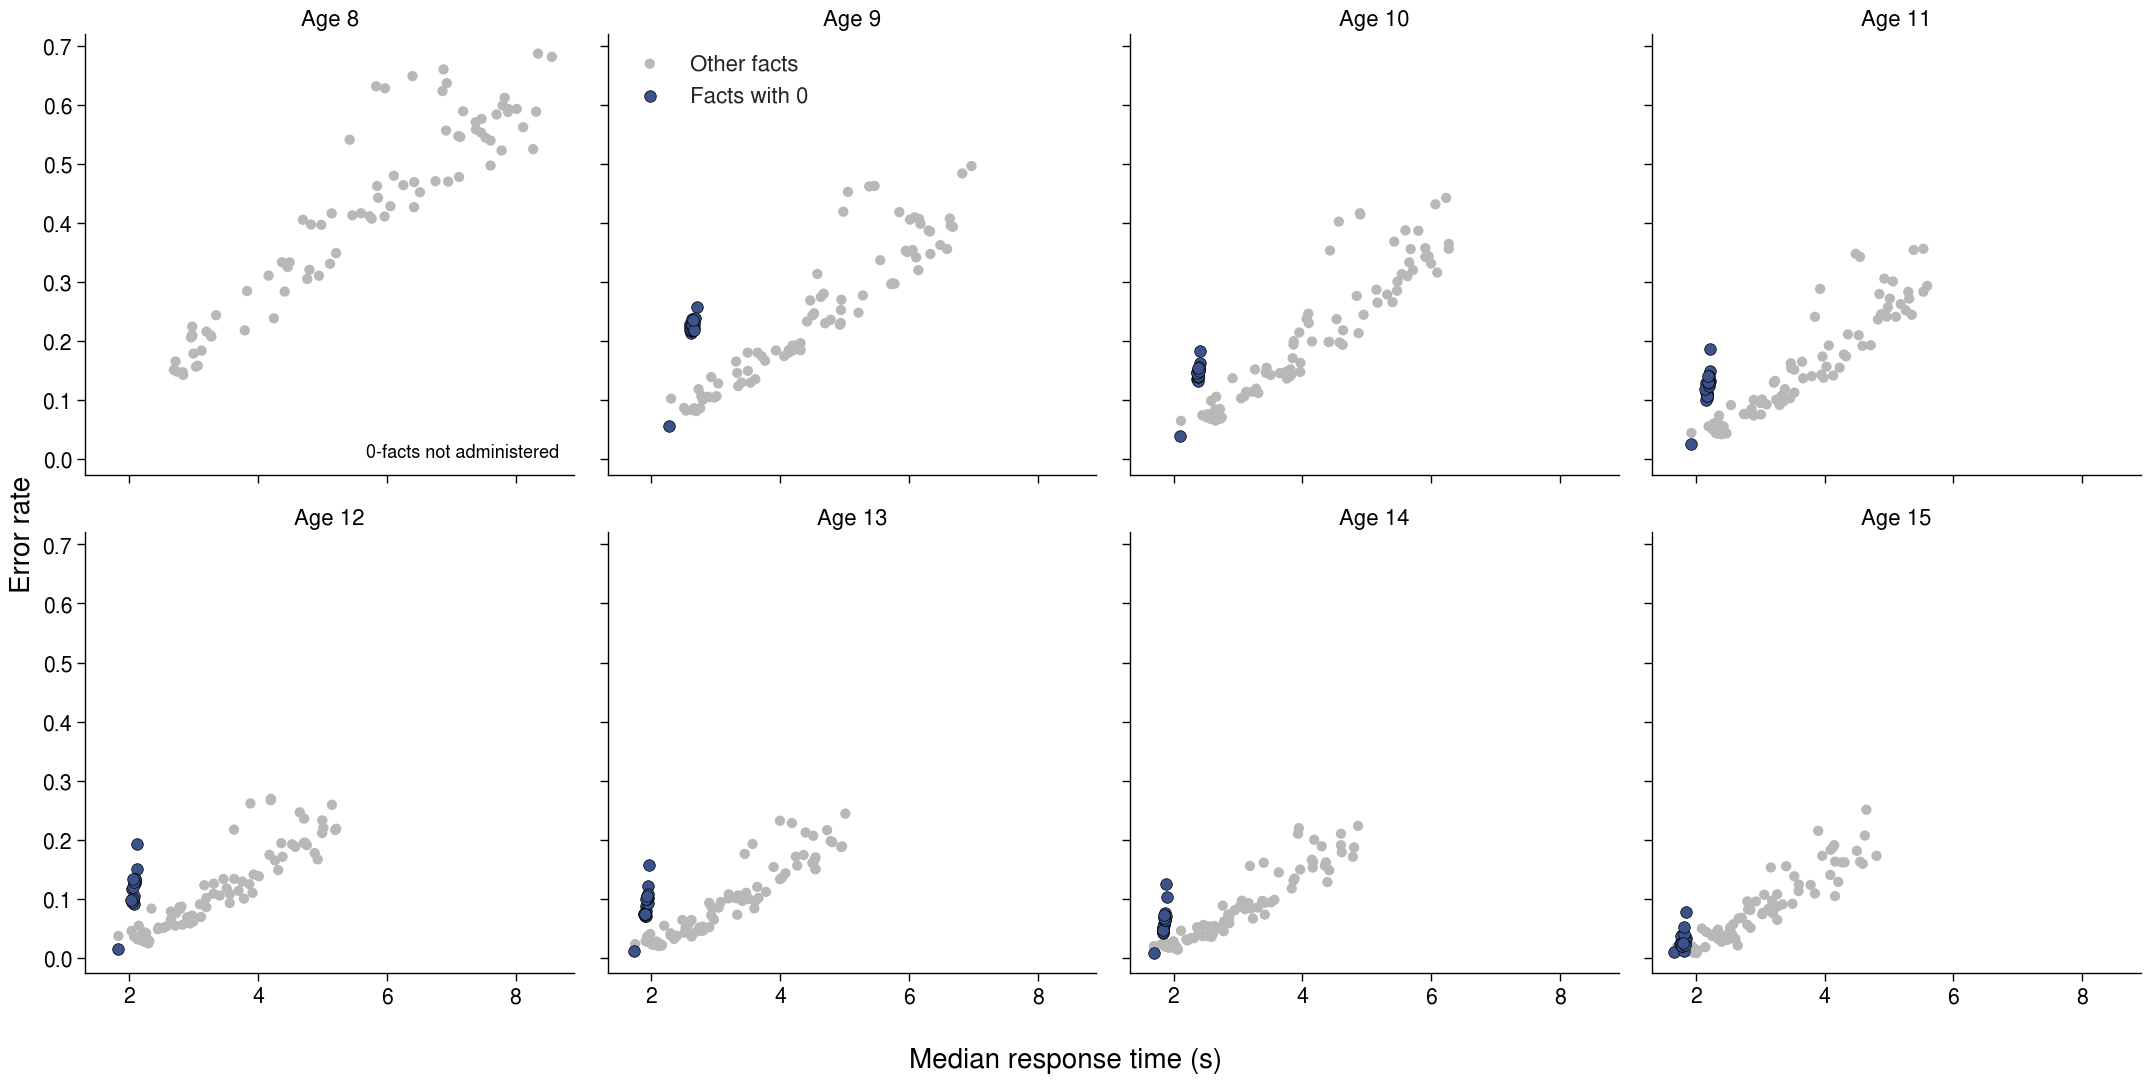

In [7]:
df_es = load_group(['ES'])
display(df_es.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_es, "rt_error_scatter_by_age_ES_all_years");

### Mexico

,facts,zero_facts,responses
course_age,,,
8,72,0,423142
9,100,19,347525
10,100,19,284323
11,100,19,261832
12,100,19,44100
13,100,19,26461


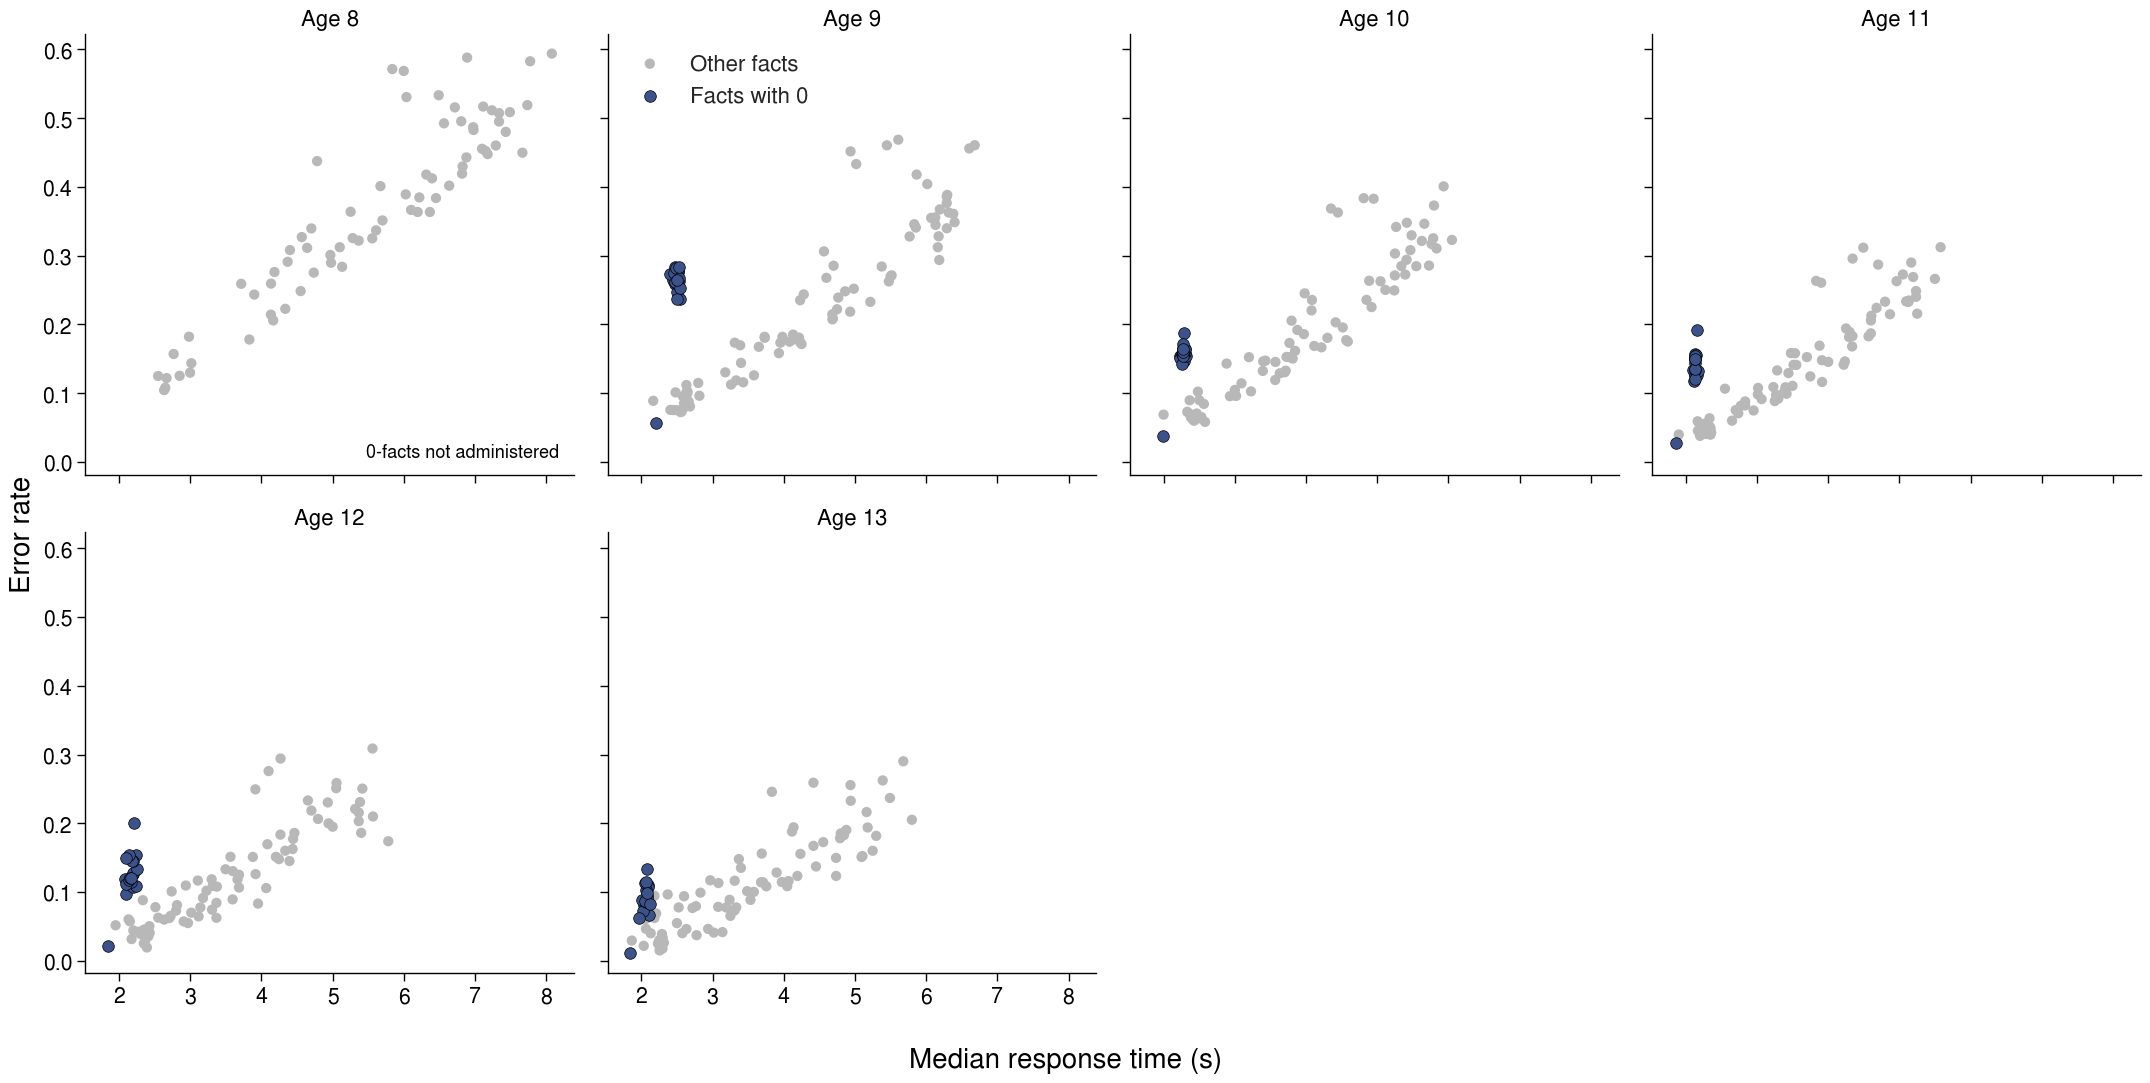

In [8]:
df_mx = load_group(['MX'])
display(df_mx.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_mx, "rt_error_scatter_by_age_MX_all_years");

### Italy

,facts,zero_facts,responses
course_age,,,
8,72,0,324650
9,100,19,199078
10,100,19,55814


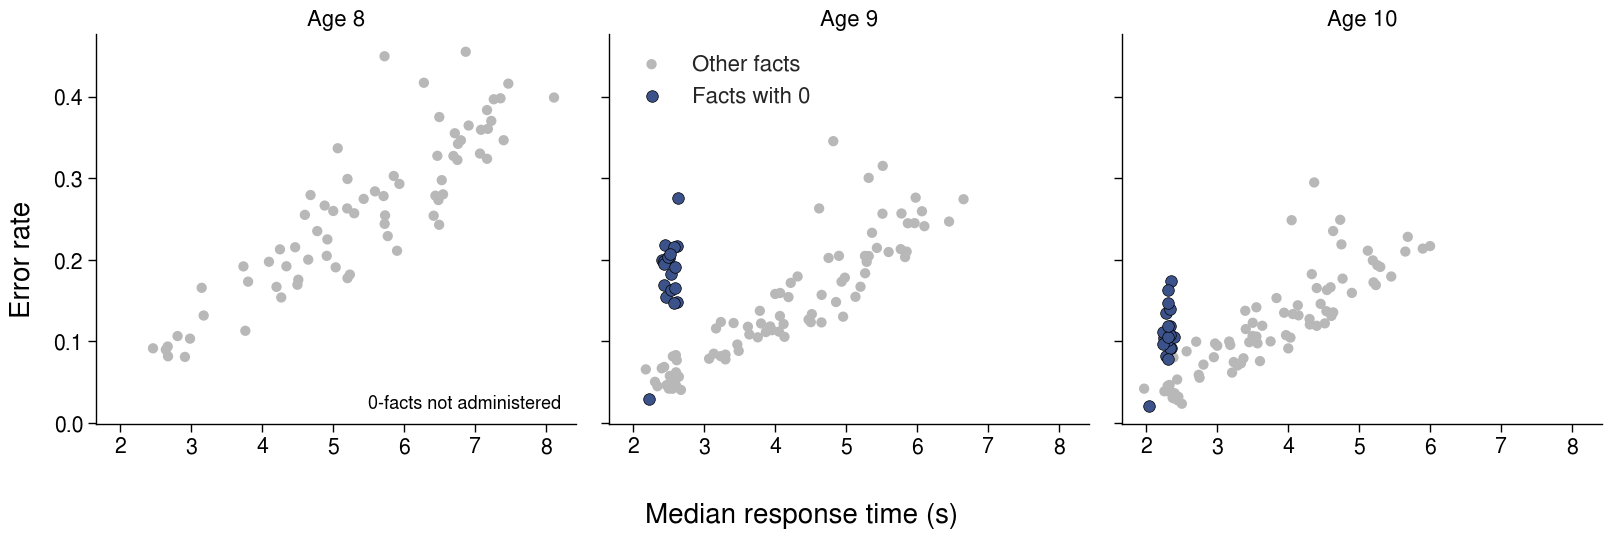

In [9]:
df_it = load_group(['IT'])
display(df_it.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_it, "rt_error_scatter_by_age_IT_all_years");

### United States

,facts,zero_facts,responses
course_age,,,
8,72,0,70578
9,100,19,55509
10,100,19,11433


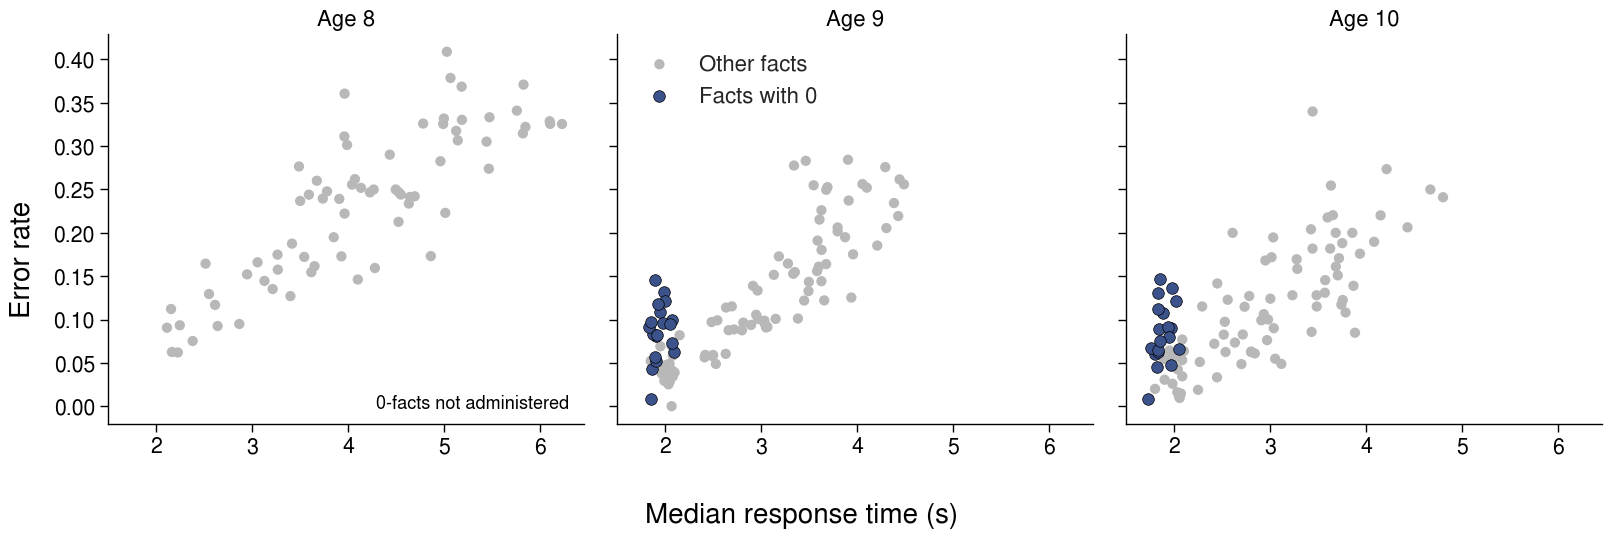

In [10]:
df_us = load_group(['US'])
display(df_us.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_us, "rt_error_scatter_by_age_US_all_years");

### Ecuador (SI)

,facts,zero_facts,responses
course_age,,,
8,72,0,39989
9,100,19,37164
10,100,19,29405
11,100,19,21269


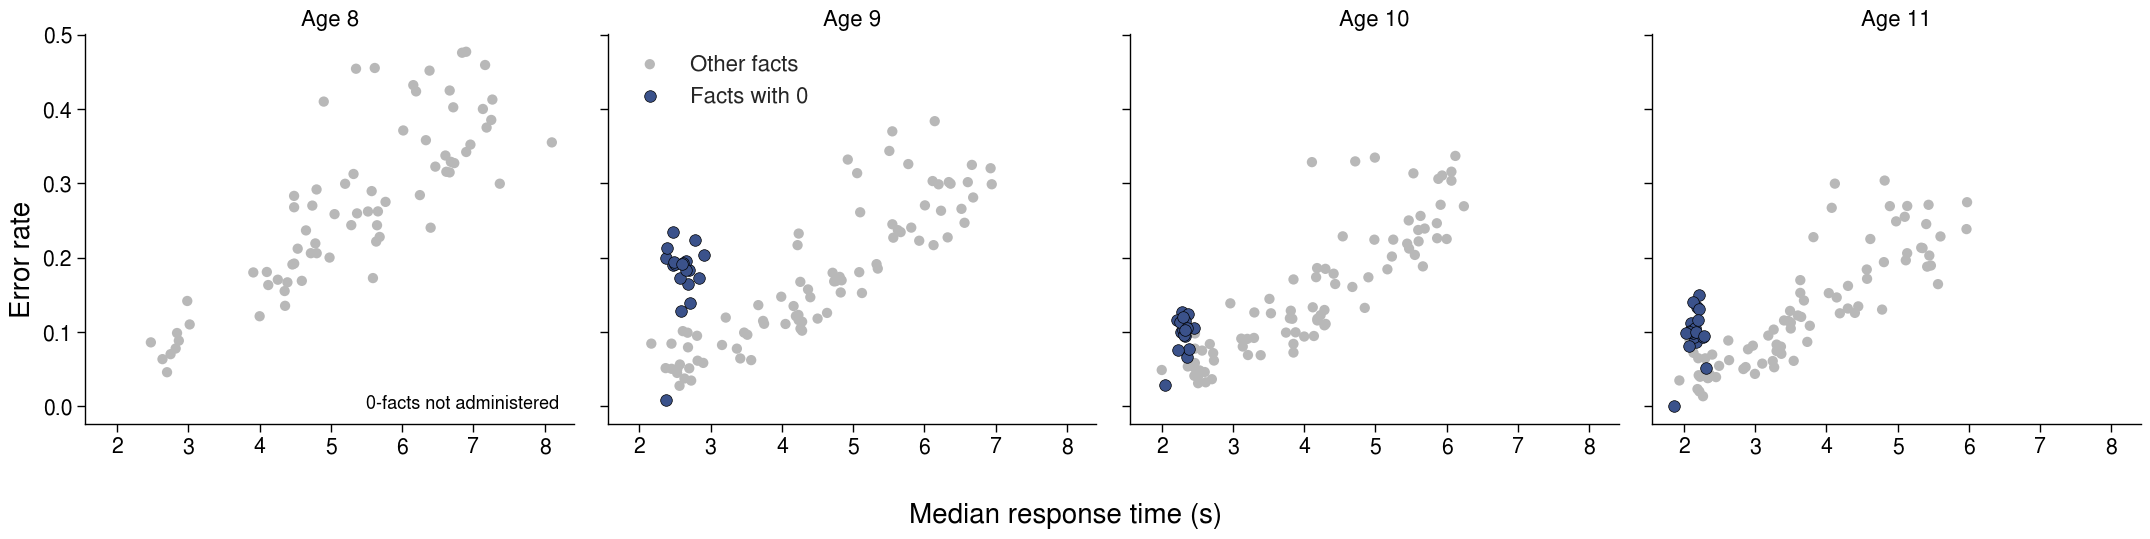

In [11]:
df_ec_si = load_group(['EC-SI'])
display(df_ec_si.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_ec_si, "rt_error_scatter_by_age_EC-SI_all_years");

### Ecuador (CO)

,facts,zero_facts,responses
course_age,,,
8,72,0,9297
9,100,19,5737
10,100,19,7161
11,100,19,8266


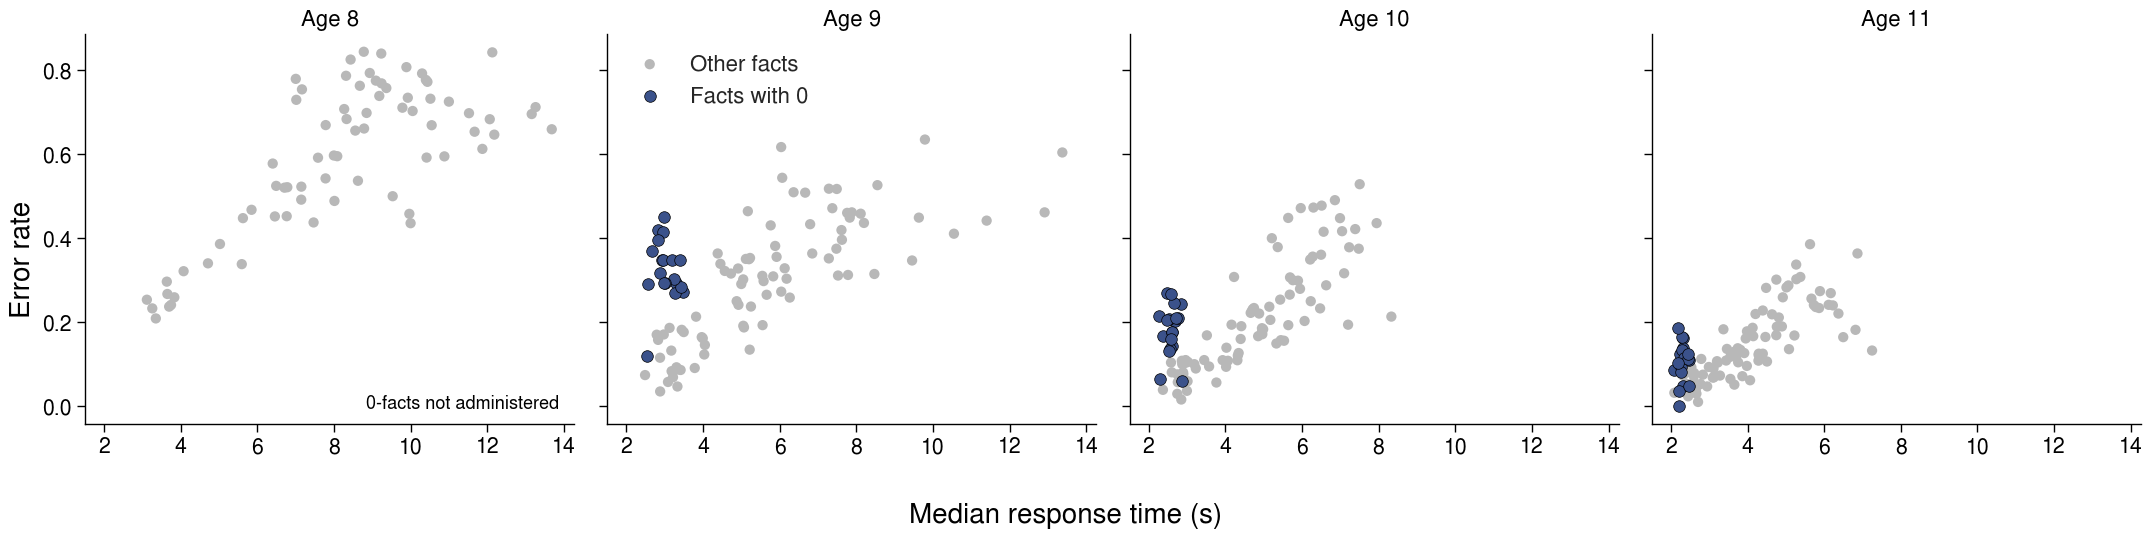

In [12]:
df_ec_co = load_group(['EC-CO'])
display(df_ec_co.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_ec_co, "rt_error_scatter_by_age_EC-CO_all_years");

### Colombia

,facts,zero_facts,responses
course_age,,,
8,72,0,32091
9,100,19,27036
10,100,19,18961
11,100,19,14915


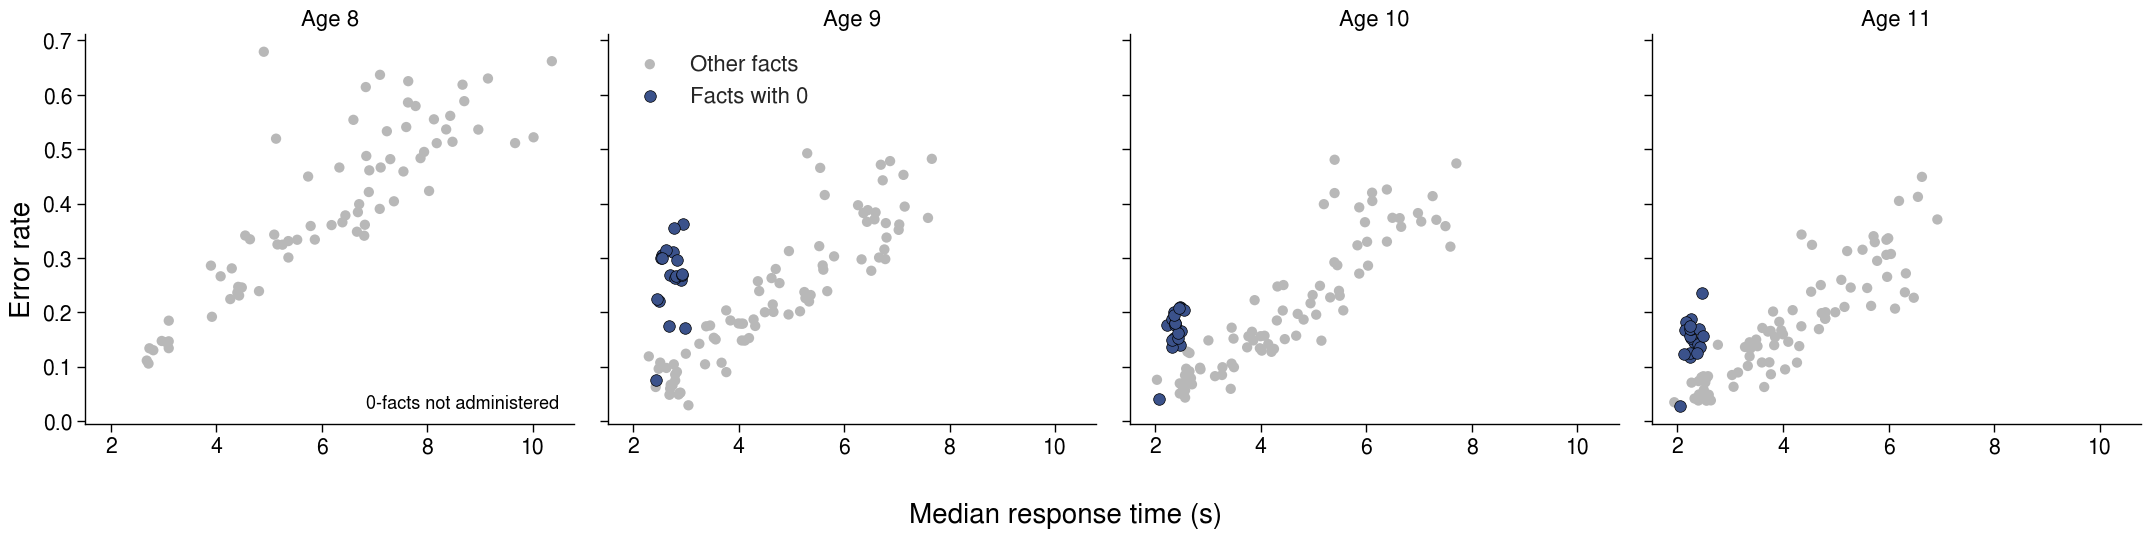

In [13]:
df_co = load_group(['CO-A', 'CO-B'])
display(df_co.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_co, "rt_error_scatter_by_age_CO_all_years");

### Chile + Brazil

,facts,zero_facts,responses
course_age,,,
8,72,0,22534
9,100,19,10476
10,100,19,7409
11,100,19,5160


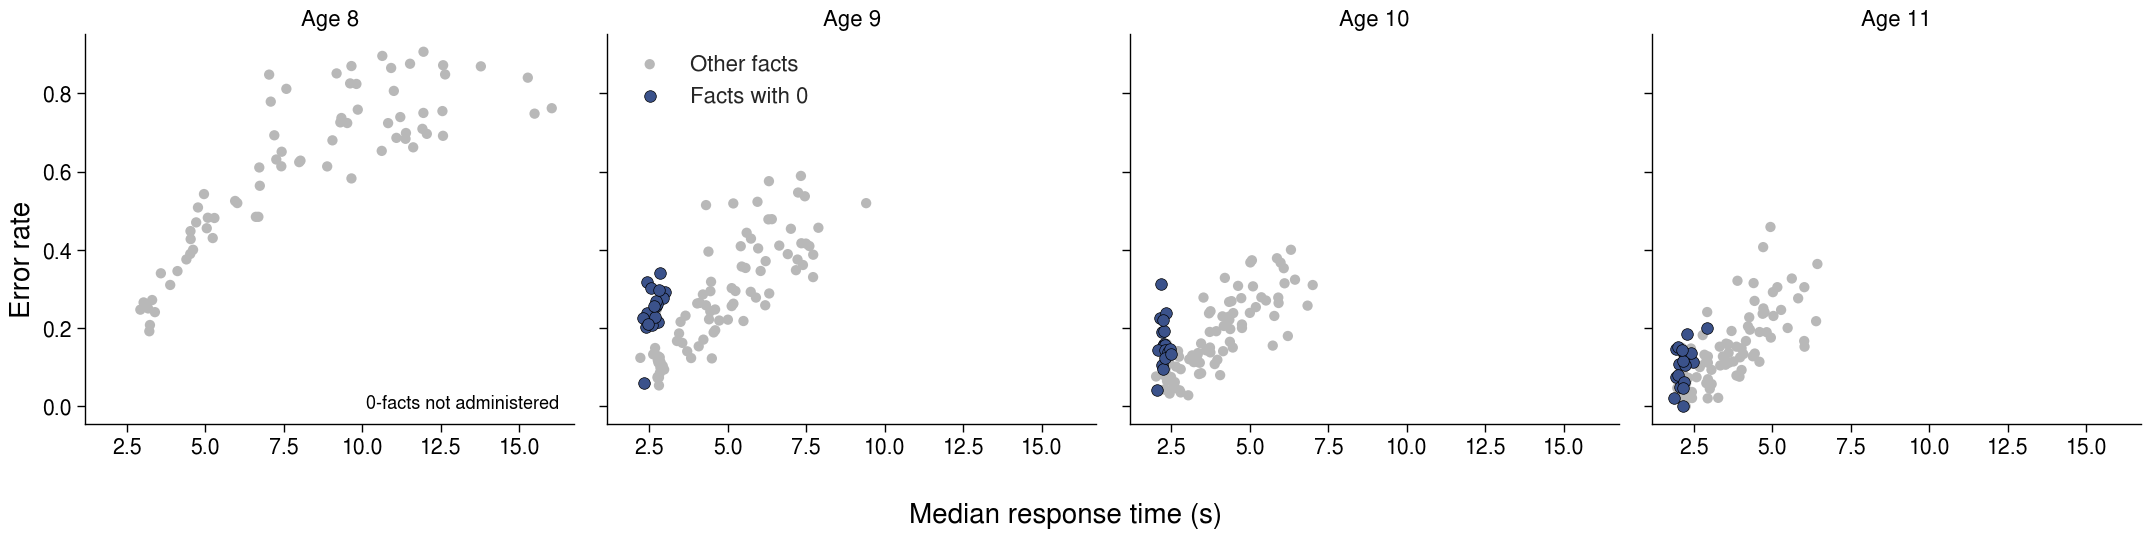

In [14]:
df_cl_br = load_group(['CL', 'BR'])
display(df_cl_br.groupby("course_age").agg(facts=("operation", "size"), zero_facts=("has_zero", "sum"),
                                  responses=("n_responses", "sum")))
plot_facts(df_cl_br, "rt_error_scatter_by_age_CL-BR_all_years");